# TechChallenge 

Projeto de Classificação de diagnóstico de câncer e mama( maligno ou benigno)
Dataset: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data


## 1. Importação de bibliotecas

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns


## 2. Carregar dados

In [12]:
df = pd.read_csv('data/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Nesta sessão eu faço a analise estatistica e descritiva dos dados do dataset a procura de anomalias ou inconsistencias para que possam ser tratadas.

In [14]:
df.shape

(569, 33)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [16]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


Após analise do dataset faço o pré-processamento dos dados para limpeza, tratar valores ausentes e inconsistentes caso seja necessário pois impactam no treinamento do modelo.

In [18]:
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})
df.head(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,1,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,1,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,1,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


## 3. Exploração dos Dados

Agora com o dataset normalizado innicio a analise quantativa e de correlação das colunas disponiveis no dataset.
Aqui queria destacar o grafico clustermap que aprendi durante meus estudos achei muito mais facil identificar as correlações utilizanndo ele.

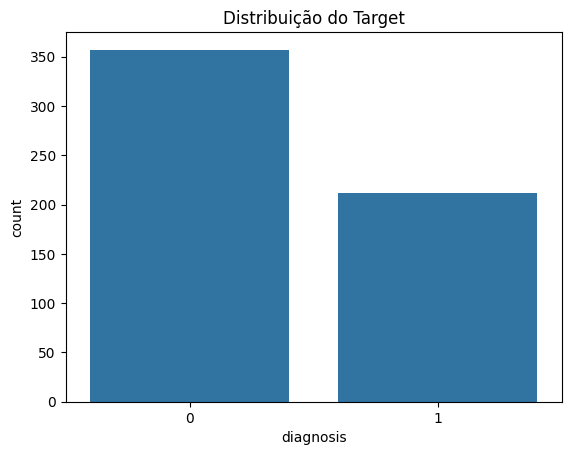

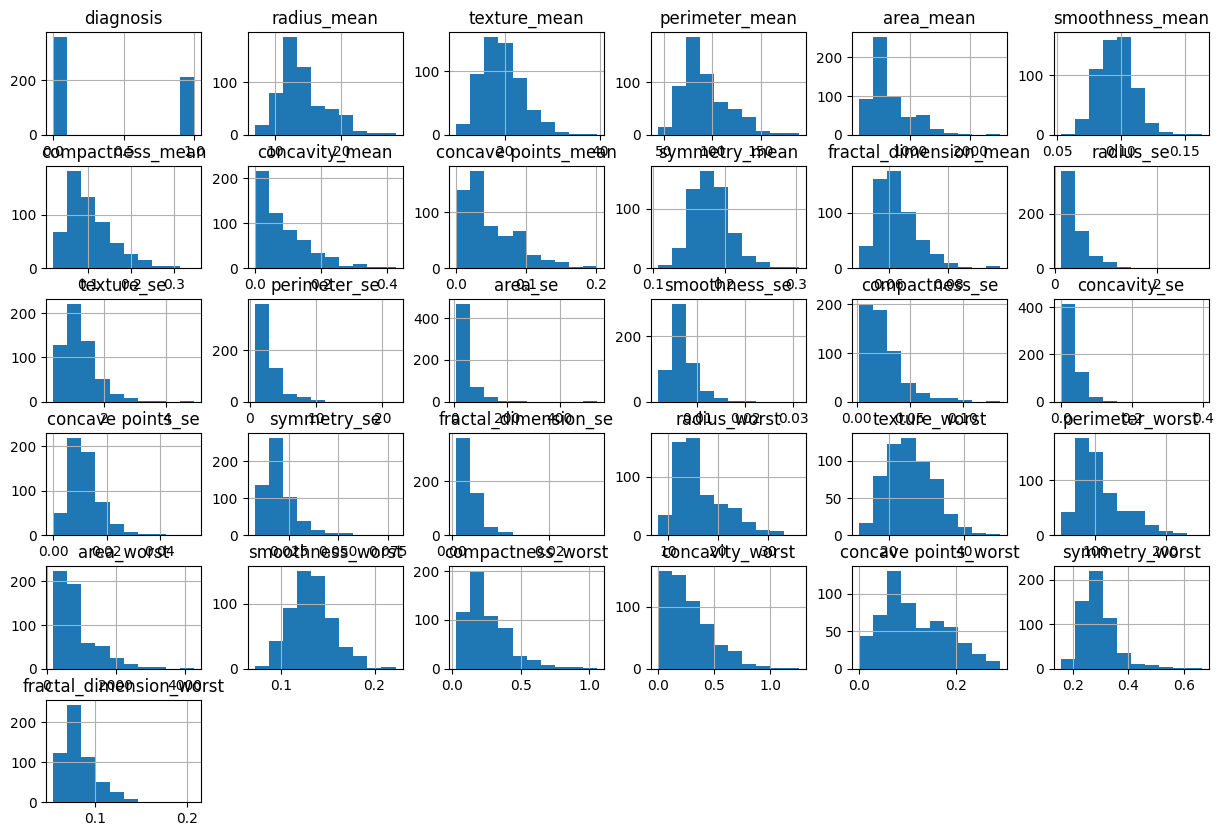

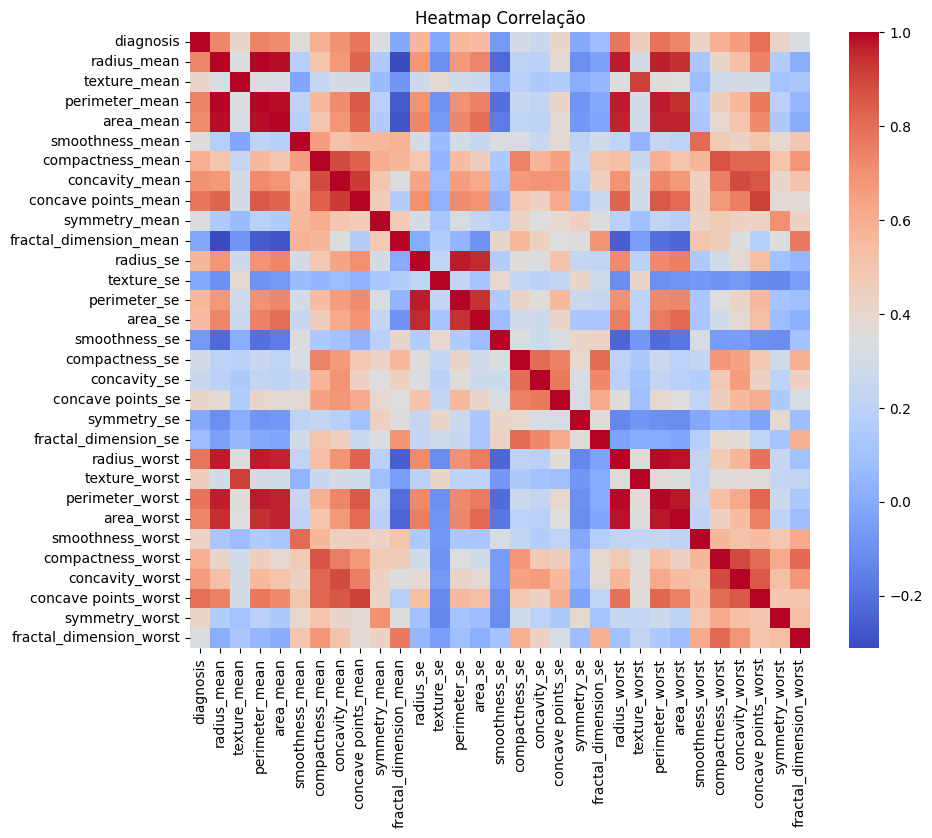

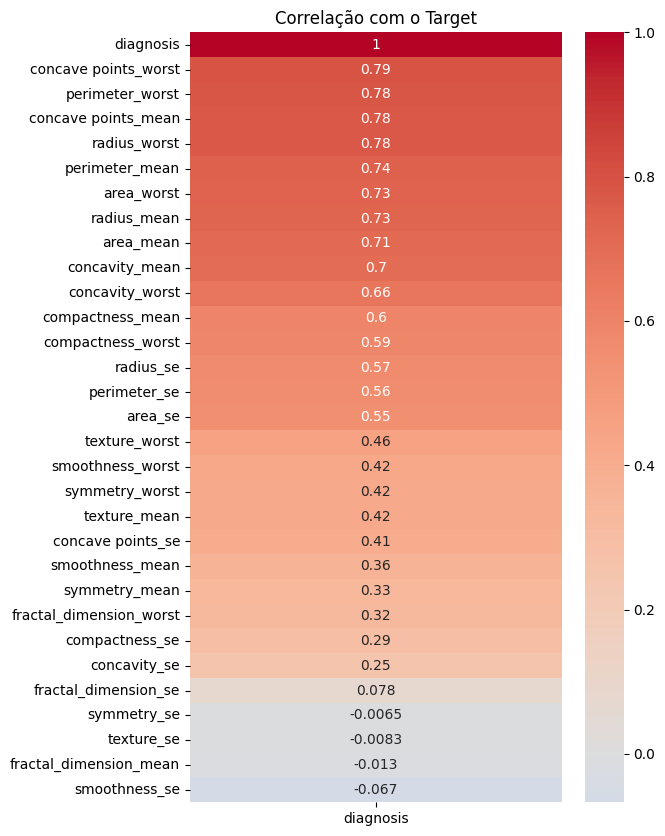

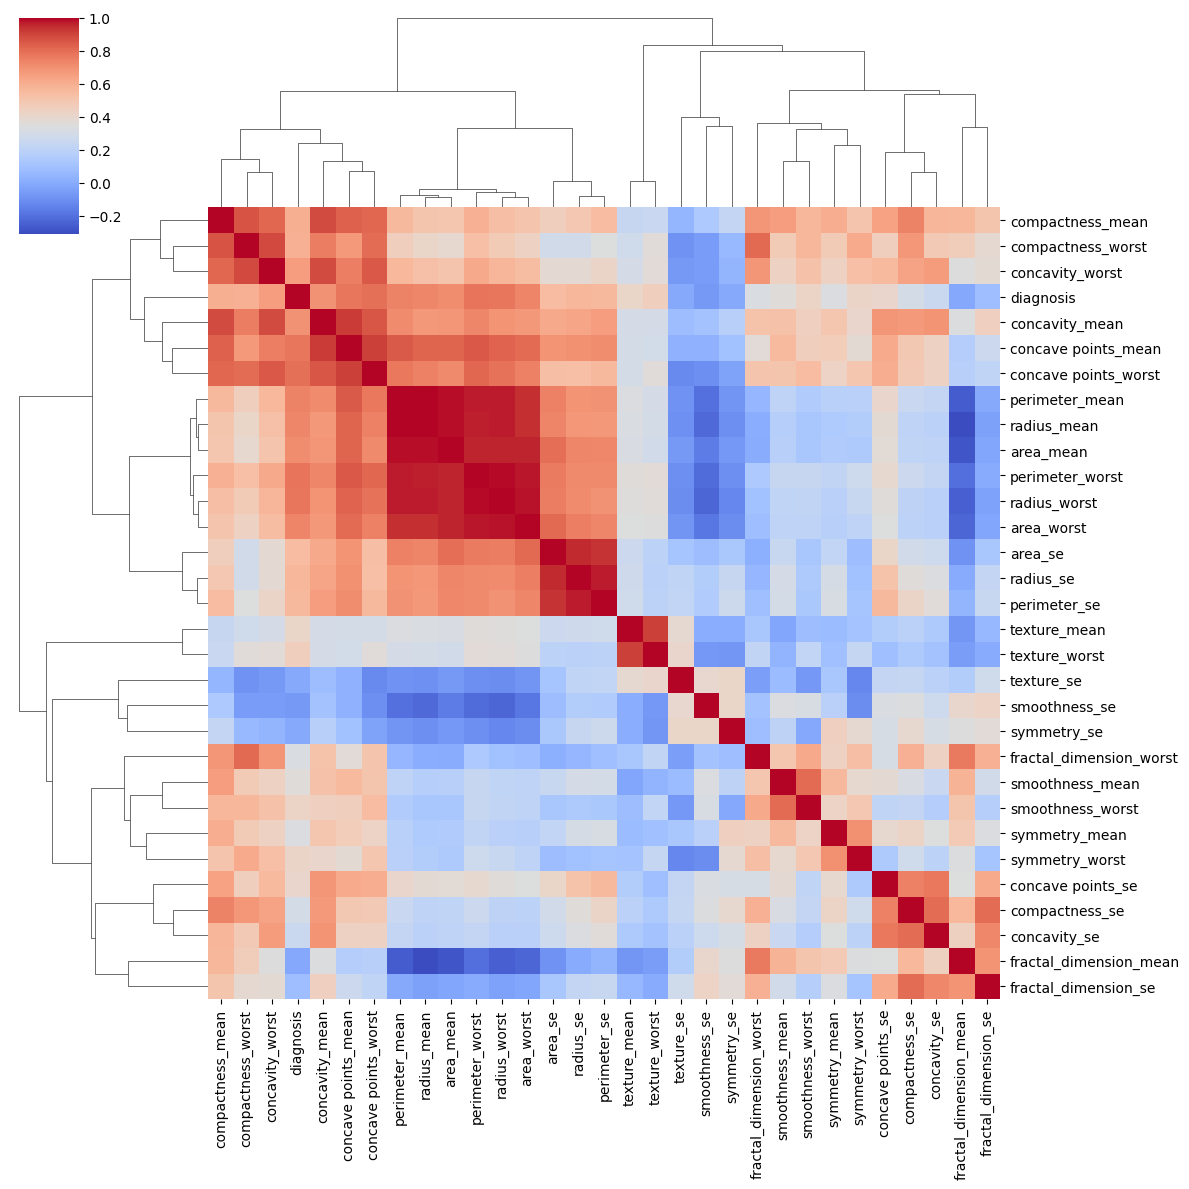

In [20]:
sns.countplot(x='diagnosis', data=df)
plt.title('Distribuição do Target')
plt.show()

df.hist(figsize=(15,10))
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Heatmap Correlação')
plt.show()

#HEATMAP
corr = df.corr(numeric_only=True)
corr_target = corr[['diagnosis']].sort_values(by='diagnosis', ascending=False)
plt.figure(figsize=(6, 10))
sns.heatmap(
    corr_target,
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title('Correlação com o Target')
plt.show()
sns.clustermap(corr, cmap='coolwarm', figsize=(12, 12))

## 4. Separação e normalização

Identificadas as correlações agora iremos fazer a separação 20% pata teste 80% para treino e normalização dos dados e claro tendo o cuidado de passsar o stratify para garantir uma distribuição proporcional de malignos/benignos no treino e non teste.

In [21]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## 5. Redução de dimensionalidade com PCA

Nesta etapa eu aplico a técnica de PCA como técnica de redução de dimencionalidade assim é possivel Detectar sobreposições caso grupo se misturem no gráfico o que dificulta a classificação e também ajuda a entender a estrutura dos dados antes de treinar.

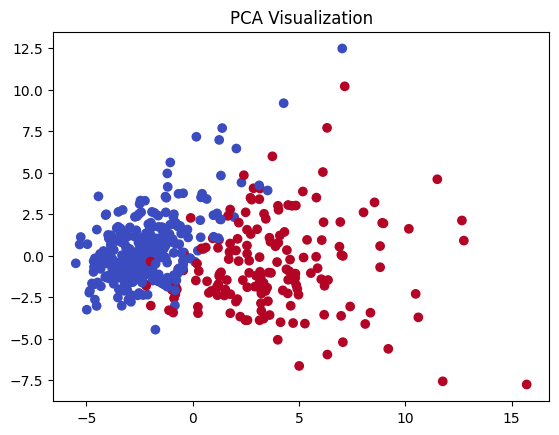

In [22]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='coolwarm')
plt.title('PCA Visualization')
plt.show()

## 6. Modelagem

Na etapa de modelagem decidi usar a LogisticRegressionn e a RandomForestClassifier do sklearn.
Eu aproveito todas as etapas anterioes até a separação de treino assim fica mais simples aplicar outras técnnicas de classificação.

In [23]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 7. Treinnamento e Avaliação dos modelos

Aqui no treinamento novamente aproveito o processo da etapa anterior criei uma mais genérica para executar a predição e assim facilitar a execução de outras técnicas.
Usei a matrix de connfusão com classification_report citada nas aulas pois também achei mais simples e informativa ela traz toda a informaçaõ necessária: precision, recall e f1-core.

Logistic Regression
[[71  1]
 [ 3 39]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Random Forest
[[72  0]
 [ 4 38]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



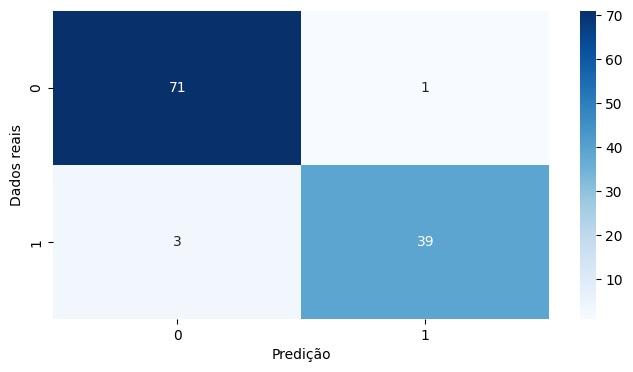

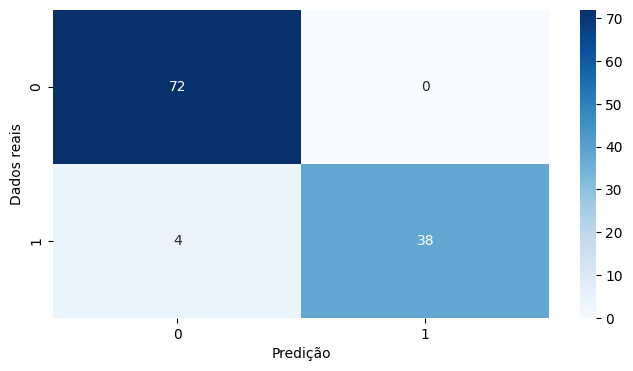

In [ ]:
def evaluate(model):
    y_predito = model.predict(X_test)

    matriz_confusao = confusion_matrix(y_test, y_predito)
    plt.figure(figsize=(8,4))
    sns.heatmap(matriz_confusao, annot=True, fmt="d", cmap="Blues")
    plt.xlabel('Predição')
    plt.ylabel('Dados reais')
    print(confusion_matrix(y_test, y_predito))
    print(classification_report(y_test, y_predito))

print("Logistic Regression")
evaluate(lr)

print("Random Forest")
evaluate(rf)


No nosso contexto de disgnóstico de câncer, recall é a metrica mais crítica: um falso negativo (dizer que um tumor maligno é benigno) é muito mais grave do que um falso positivo.
por isso usar classification_report para analisar as metricas de contexto é importante.

## 8. Feature Importance (Random Forest)

A Feature importannce esta disponivel para Random Forest e mostra quais variaveis maiss innfluenciam na decisão do modelo. Ela ajuda a justificar a decisão do modelo para profissionais  de saúde, que precisam entennder o "porquê" antes de confiar numa predição. A ultima palavra é sempre do médico.

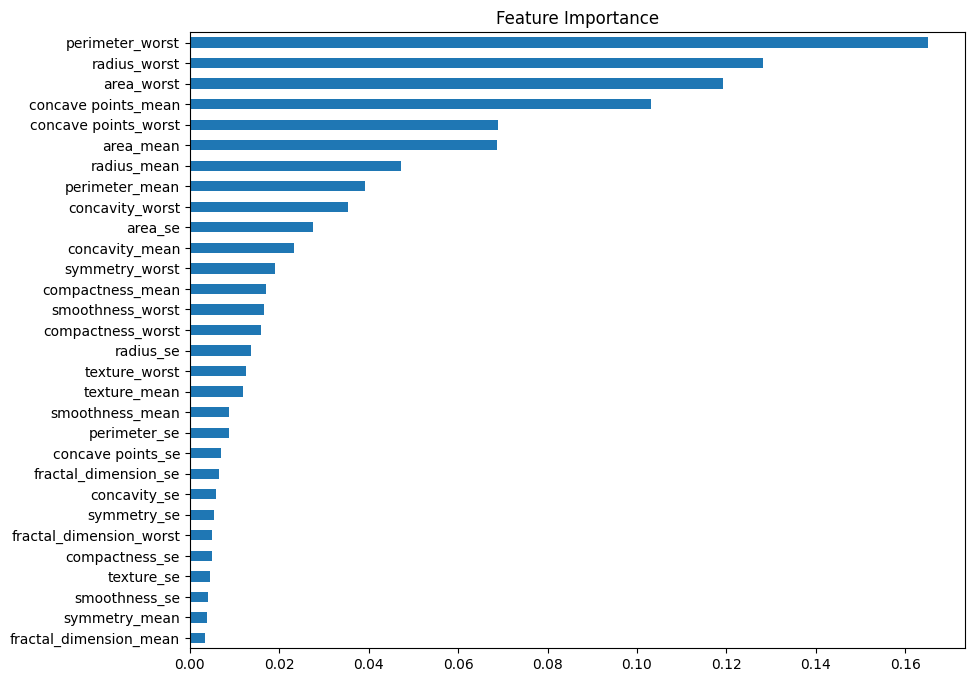

In [25]:
importances = rf.feature_importances_
feat = pd.Series(importances, index=X.columns)
feat.sort_values().plot(kind='barh', figsize=(10,8))
plt.title('Feature Importance')
plt.show()

## 9. Discussão Crítica dos Resultados

In [ ]:
from sklearn.metrics import recall_score, accuracy_score, f1_score

modelos = {"Logistic Regression": lr, "Random Forest": rf}

print(f"{"Modelo":<25} {"Accuracy":<12} {"Recall (maligno)":<20} {"F1 (maligno)":<15} {"Falsos Negativos"}")
print("-" * 85)

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    fn  = ((y_test == 1) & (y_pred == 0)).sum()
    print(f"{nome:<25} {acc:<12.4f} {rec:<20.4f} {f1:<15.4f} {fn}")


### Análise das métricas

No diagnóstico de câncer de mama, **recall da classe maligna (1) é a métrica mais crítica**. 
Um falso negativo — classificar um tumor maligno como benigno — significa que o paciente 
pode não receber tratamento a tempo, com consequências graves ou fatais. 
Um falso positivo, embora cause ansiedade desnecessária, resulta em exames adicionais 
que desmistificam o diagnóstico.

Por isso, ao comparar os dois modelos, priorizamos aquele com **maior recall para a classe 1 (maligno)**, 
mesmo que isso implique leve queda em precisão.

---

### O modelo pode ser usado na prática?

Os modelos treinados demonstram desempenho alto neste dataset. No entanto, alguns pontos devem ser considerados antes de qualquer uso clínico real:

**Pontos positivos:**
- Alta acurácia e recall elevado para tumores malignos indicam boa capacidade discriminativa
- As features mais importantes (como ,  e ) têm correlação clínica conhecida com malignidade
- O modelo é transparente: a Feature Importance permite que o médico entenda quais características influenciaram a predição

**Limitações importantes:**
- O dataset é pequeno (569 amostras) e pode não representar toda a diversidade populacional
- Os dados são provenientes de uma única instituição (University of Wisconsin), o que pode introduzir viés
- O modelo não foi validado em dados externos (validação cruzada institucional)
- Não considera fatores clínicos relevantes como histórico familiar, idade e resultados de outros exames

**Como poderia ser usado:**
O modelo tem potencial como **ferramenta de apoio à decisão** — não como substituto do médico. 
Um fluxo possível seria: o modelo analisa os dados da biópsia e sinaliza casos de alta suspeita de malignidade, 
priorizando-os para revisão médica imediata. Casos sinalizados como benignos ainda passariam por revisão, 
mas com menor urgência.

> **O médico sempre tem a palavra final.** O modelo é uma ferramenta auxiliar que pode aumentar a eficiência 
e reduzir erros humanos por fadiga, mas nunca deve substituir o julgamento clínico profissional. 
Decisões de tratamento devem sempre ser tomadas por um especialista qualificado com base no quadro completo do paciente.